# Single-Period Unit Commitment Using QAOA

This notebook explores quantum optimisation for a renewable-heavy electricity grid using the PGLib-UC RTS-GMLC benchmark.

The objective is to determine which thermal generators should operate to minimise generation and startup costs while satisfying electricity demand, reserve requirements, and renewable generation limits.

We first construct an exact classical benchmark for a simplified single-period problem, then formulate a QUBO and solve it using standard QAOA and CVaR-QAOA implemented in Qiskit.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../data/2020-01-27.json")

with open(DATA_PATH, "r") as f:
    data = json.load(f)

print("Time periods:", data["time_periods"])
print("Thermal generators:", len(data["thermal_generators"]))
print("Renewable generators:", len(data["renewable_generators"]))

Time periods: 48
Thermal generators: 73
Renewable generators: 81


In [2]:
thermal = pd.DataFrame.from_dict(
    data["thermal_generators"],
    orient="index"
)

renewable = pd.DataFrame.from_dict(
    data["renewable_generators"],
    orient="index"
)

demand = pd.DataFrame({
    "Period": range(1, data["time_periods"] + 1),
    "Demand_MW": data["demand"],
    "Reserve_MW": data["reserves"]
})

display(thermal.head())
display(renewable.head())
display(demand.head())

,must_run,power_output_minimum,power_output_maximum,ramp_up_limit,ramp_down_limit,ramp_startup_limit,ramp_shutdown_limit,time_up_minimum,time_down_minimum,power_output_t0,unit_on_t0,time_down_t0,time_up_t0,startup,piecewise_production,name
115_STEAM_1,0,5.0,12.0,20.0,20.0,5.0,5.0,4,2,0.0,0,168,0,"[{'lag': 2, 'cost': 393.28}, {'lag': 4, 'cost'...","[{'mw': 5.0, 'cost': 897.29}, {'mw': 7.33, 'co...",115_STEAM_1
101_CT_1,0,8.0,20.0,60.0,60.0,8.0,8.0,1,1,0.0,0,28,0,"[{'lag': 1, 'cost': 51.75}]","[{'mw': 8.0, 'cost': 1085.78}, {'mw': 12.0, 'c...",101_CT_1
101_CT_2,0,8.0,20.0,60.0,60.0,8.0,8.0,1,1,0.0,0,28,0,"[{'lag': 1, 'cost': 51.75}]","[{'mw': 8.0, 'cost': 1085.78}, {'mw': 12.0, 'c...",101_CT_2
213_CT_2,0,22.0,55.0,74.0,74.0,22.0,22.0,3,3,0.0,0,168,0,"[{'lag': 3, 'cost': 5665.23}]","[{'mw': 22.0, 'cost': 1122.43}, {'mw': 33.0, '...",213_CT_2
301_CT_1,0,8.0,20.0,60.0,60.0,8.0,8.0,1,1,0.0,0,168,0,"[{'lag': 1, 'cost': 51.75}]","[{'mw': 8.0, 'cost': 1208.23}, {'mw': 12.0, 'c...",301_CT_1


,power_output_minimum,power_output_maximum,name
118_RTPV_9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 4.1, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 4.1, ...",118_RTPV_9
101_PV_3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.5, 20.0...",101_PV_3
314_PV_2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 26.5, 35.5...",314_PV_2
215_PV_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 69.4, 87.1...",215_PV_1
118_RTPV_4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 3.8, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 3.8, ...",118_RTPV_4


,Period,Demand_MW,Reserve_MW
0,1,3262.31,97.8693
1,2,3215.96,96.4788
2,3,3220.90,96.6270
3,4,3274.01,98.2203
4,5,3435.74,103.0722


## Reduced Grid Instance

The original benchmark contains 73 thermal generators, 81 renewable generators, and 48 scheduling periods. Simulating a quantum circuit for the complete problem would be computationally impractical.

We therefore select six thermal generators, one wind generator, and one solar generator.

System demand and reserve requirements are scaled according to the selected thermal generating capacity, while the selected renewable availability profiles are preserved.

We optimise period 11 (Python index 10). This produces a constructed benchmark-derived test scenario rather than a complete representation of the original grid.

In [3]:
import itertools
from pathlib import Path

# 1. Select thermal generators from the original benchmark
thermal_ids = [
    "221_CC_1",
    "202_STEAM_3",
    "101_STEAM_4",
    "315_CT_6",
    "213_CT_1",
    "101_CT_1"
]

# 2. Select renewable generators
renewable_ids = [
    "309_WIND_1",
    "101_PV_3"
]

# 3. Extract their original data
selected_thermal = {
    name: data["thermal_generators"][name]
    for name in thermal_ids
}

selected_renewable = {
    name: data["renewable_generators"][name]
    for name in renewable_ids
}

# 4. Scale system demand according to selected thermal capacity
original_capacity = sum(
    g["power_output_maximum"]
    for g in data["thermal_generators"].values()
)

selected_capacity = sum(
    g["power_output_maximum"]
    for g in selected_thermal.values()
)

scale_factor = selected_capacity / original_capacity

reduced_demand = [
    round(d * scale_factor, 5)
    for d in data["demand"]
]

reduced_reserves = [
    round(r * scale_factor, 5)
    for r in data["reserves"]
]

# 5. Assemble the reduced benchmark
reduced_data = {
    "time_periods": data["time_periods"],
    "demand": reduced_demand,
    "reserves": reduced_reserves,
    "thermal_generators": selected_thermal,
    "renewable_generators": selected_renewable,
    "_metadata": {
        "source": "PGLib-UC RTS-GMLC 2020-01-27",
        "demand_scale_factor": scale_factor,
        "description": "Reduced benchmark-derived test scenario"
    }
}

# 6. Save the new dataset
data_dir = (
    Path("../data")
    if Path("../data/2020-01-27.json").exists()
    else Path("data")
)

output_path = data_dir / "reduced_instance.json"

with open(output_path, "w") as f:
    json.dump(reduced_data, f, indent=2)

# 7. Display the selected thermal generators
generator_table = pd.DataFrame([
    {
        "Generator": name,
        "Min MW": g["power_output_minimum"],
        "Max MW": g["power_output_maximum"],
        "Initially ON": g["unit_on_t0"],
        "Min Production Cost": g["piecewise_production"][0]["cost"]
    }
    for name, g in selected_thermal.items()
])

display(generator_table)

# 8. Select time period 11 (Python index 10)
period = 10

demand_mw = reduced_demand[period]
reserve_mw = reduced_reserves[period]

renewable_available = {
    name: g["power_output_maximum"][period]
    for name, g in selected_renewable.items()
}

total_renewable = sum(renewable_available.values())

print(f"Original thermal capacity: {original_capacity:.2f} MW")
print(f"Selected thermal capacity: {selected_capacity:.2f} MW")
print(f"Demand scaling factor: {scale_factor:.4f}")
print(f"Reduced demand: {demand_mw:.2f} MW")
print(f"Reserve requirement: {reserve_mw:.2f} MW")
print(f"Renewable availability: {renewable_available}")
print(f"Total renewable availability: {total_renewable:.2f} MW")
print(f"Net demand after full renewable use: {demand_mw - total_renewable:.2f} MW")

# 9. Basic capacity feasibility check
feasible_patterns = 0

for bits in itertools.product([0, 1], repeat=len(thermal_ids)):
    p_min = sum(
        selected_thermal[name]["power_output_minimum"] * on
        for name, on in zip(thermal_ids, bits)
    )

    p_max = sum(
        selected_thermal[name]["power_output_maximum"] * on
        for name, on in zip(thermal_ids, bits)
    )

    if p_min <= demand_mw and p_max + total_renewable >= demand_mw + reserve_mw:
        feasible_patterns += 1

print(f"Commitments passing basic capacity check: {feasible_patterns}/64")
print(f"Saved reduced dataset to: {output_path}")

,Generator,Min MW,Max MW,Initially ON,Min Production Cost
0,221_CC_1,170.0,355.0,1,4551.12
1,202_STEAM_3,30.0,76.0,1,751.27
2,101_STEAM_4,30.0,76.0,1,841.58
3,315_CT_6,22.0,55.0,0,884.44
4,213_CT_1,22.0,55.0,0,1122.43
5,101_CT_1,8.0,20.0,0,1085.78


Original thermal capacity: 8076.00 MW
Selected thermal capacity: 637.00 MW
Demand scaling factor: 0.0789
Reduced demand: 318.61 MW
Reserve requirement: 9.56 MW
Renewable availability: {'309_WIND_1': 148.3, '101_PV_3': 20.4}
Total renewable availability: 168.70 MW
Net demand after full renewable use: 149.91 MW
Commitments passing basic capacity check: 43/64
Saved reduced dataset to: ..\data\reduced_instance.json


## Classical Baseline: Exhaustive Unit Commitment and Economic Dispatch

With six thermal generators, there are 2^6 = 64 possible ON/OFF configurations.

For each configuration, we solve a linear programming problem using SciPy's `linprog` to determine the minimum-cost power output of the committed generators.

The optimisation considers:

- Power balance between generation and demand
- Minimum and maximum thermal generator output
- Available wind and solar generation
- Thermal reserve capacity
- Piecewise-linear production costs and estimated startup costs

Infeasible configurations are rejected. The lowest-cost feasible configuration is the global optimum of this simplified single-period model.

Chronological constraints such as ramping and minimum ON/OFF durations are not enforced in this experiment.

In [4]:
import itertools
import json
from pathlib import Path
import pandas as pd
from scipy.optimize import linprog

# Use variables created in our previous cells
D = float(reduced_data["demand"][period])
R = float(reduced_data["reserves"][period])

renewable_max = {
    name: float(selected_renewable[name]["power_output_maximum"][period])
    for name in renewable_ids
}

# Check that the selected piecewise cost curves are convex
for name in thermal_ids:
    curve = selected_thermal[name]["piecewise_production"]

    slopes = [
        (curve[j+1]["cost"] - curve[j]["cost"]) /
        (curve[j+1]["mw"] - curve[j]["mw"])
        for j in range(len(curve)-1)
    ]

    assert all(
        slopes[j+1] >= slopes[j] - 1e-7
        for j in range(len(slopes)-1)
    ), f"Nonconvex cost curve: {name}"


def solve_dispatch(bits):
    """
    Solve minimum-cost economic dispatch for
    a given 6-bit generator commitment.
    """

    on_ids = [
        name for name, on in zip(thermal_ids, bits)
        if on == 1
    ]

    if not on_ids:
        return None

    p_min_total = sum(
        selected_thermal[name]["power_output_minimum"]
        for name in on_ids
    )

    p_max_total = sum(
        selected_thermal[name]["power_output_maximum"]
        for name in on_ids
    )

    # Basic feasibility checks
    if p_min_total > D + 1e-8:
        return None

    if p_max_total + sum(renewable_max.values()) < D + R - 1e-8:
        return None

    var_names = []
    var_costs = []
    bounds = []

    production_base_cost = 0.0
    startup_cost = 0.0

    for name in on_ids:
        g = selected_thermal[name]
        curve = g["piecewise_production"]

        production_base_cost += curve[0]["cost"]

        # Approximate startup cost using initial ON/OFF status
        if g["unit_on_t0"] == 0:
            down_time = g["time_down_t0"]

            eligible = [
                x for x in g["startup"]
                if x["lag"] <= down_time
            ]

            chosen = (
                max(eligible, key=lambda x: x["lag"])
                if eligible
                else min(g["startup"], key=lambda x: x["lag"])
            )

            startup_cost += chosen["cost"]

        # Piecewise-linear production costs
        for j in range(len(curve) - 1):
            width = curve[j+1]["mw"] - curve[j]["mw"]

            slope = (
                curve[j+1]["cost"] - curve[j]["cost"]
            ) / width

            var_names.append(("thermal_segment", name))
            var_costs.append(slope)
            bounds.append((0, width))

    # Renewable utilisation variables
    for name in renewable_ids:
        var_names.append(("renewable", name))
        var_costs.append(0.0)
        bounds.append((0, renewable_max[name]))

    # Reserve is supplied by unused thermal capacity
    reserve_coefficients = [
        1.0 if kind == "thermal_segment" else 0.0
        for kind, name in var_names
    ]

    # Solve continuous dispatch
    lp = linprog(
        c=var_costs,

        # Power balance
        A_eq=[[1.0] * len(var_names)],
        b_eq=[D - p_min_total],

        # Thermal reserve constraint
        A_ub=[reserve_coefficients],
        b_ub=[p_max_total - p_min_total - R],

        bounds=bounds,
        method="highs"
    )

    if not lp.success:
        return None

    # Recover actual generator power outputs
    thermal_dispatch = {
        name: float(
            selected_thermal[name]["power_output_minimum"]
        )
        for name in on_ids
    }

    renewable_used = {
        name: 0.0 for name in renewable_ids
    }

    for (kind, name), value in zip(var_names, lp.x):
        if kind == "thermal_segment":
            thermal_dispatch[name] += float(value)
        else:
            renewable_used[name] = float(value)

    total_thermal = sum(thermal_dispatch.values())
    total_renewable = sum(renewable_used.values())

    reserve_headroom = p_max_total - total_thermal

    # Verify physical constraints
    assert abs(total_thermal + total_renewable - D) < 1e-5
    assert reserve_headroom + 1e-5 >= R

    return {
        "bitstring": "".join(map(str, bits)),
        "num_on": len(on_ids),

        "total_cost": float(
            production_base_cost + startup_cost + lp.fun
        ),

        "startup_cost": float(startup_cost),

        "production_cost": float(
            production_base_cost + lp.fun
        ),

        "thermal_mw": float(total_thermal),
        "renewable_used_mw": float(total_renewable),

        "renewable_curtailed_mw": float(
            sum(renewable_max.values()) - total_renewable
        ),

        "reserve_headroom_mw": float(reserve_headroom),
        "thermal_dispatch": thermal_dispatch,
        "renewable_dispatch": renewable_used
    }


# Evaluate every possible ON/OFF combination
all_solutions = [
    solve_dispatch(bits)
    for bits in itertools.product(
        (0, 1), repeat=len(thermal_ids)
    )
]

# Keep feasible solutions and sort by cost
feasible_solutions = sorted(
    (s for s in all_solutions if s is not None),
    key=lambda s: s["total_cost"]
)

assert feasible_solutions, "No feasible solutions found"

best = feasible_solutions[0]

print("Feasible combinations:", len(feasible_solutions))
print("Optimal bitstring:", best["bitstring"])
print("Minimum cost:", round(best["total_cost"], 2))
print("Renewable curtailment:",
      round(best["renewable_curtailed_mw"], 2), "MW")
print("Reserve headroom:",
      round(best["reserve_headroom_mw"], 2), "MW")

print("\nThermal dispatch:")
for name, power in best["thermal_dispatch"].items():
    print(f"  {name}: {power:.2f} MW")

print("\nRenewable dispatch:")
for name, power in best["renewable_dispatch"].items():
    print(f"  {name}: {power:.2f} MW")

Feasible combinations: 43
Optimal bitstring: 011001
Minimum cost: 4278.46
Renewable curtailment: 0.0 MW
Reserve headroom: 22.09 MW

Thermal dispatch:
  202_STEAM_3: 65.91 MW
  101_STEAM_4: 76.00 MW
  101_CT_1: 8.00 MW

Renewable dispatch:
  309_WIND_1: 148.30 MW
  101_PV_3: 20.40 MW


In [5]:
summary_cols = [
    "bitstring",
    "num_on",
    "total_cost",
    "production_cost",
    "startup_cost",
    "thermal_mw",
    "renewable_used_mw",
    "renewable_curtailed_mw",
    "reserve_headroom_mw"
]

results_df = pd.DataFrame([
    {k: solution[k] for k in summary_cols}
    for solution in feasible_solutions
])

# Save alongside the reduced benchmark's data directory
results_dir = output_path.parent.parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    results_dir / "classical_results.csv",
    index=False
)

with open(results_dir / "classical_best.json", "w") as f:
    json.dump({
        "generator_order": thermal_ids,
        "period": period + 1,
        "demand_mw": D,
        "reserve_mw": R,
        "best_solution": best
    }, f, indent=2)

display(results_df.head(10))

print("Classical results saved successfully.")

,bitstring,num_on,total_cost,production_cost,startup_cost,thermal_mw,renewable_used_mw,renewable_curtailed_mw,reserve_headroom_mw
0,011001,3,4278.459539,4226.709539,51.75,149.90806,168.70000,0.00000,22.09194
1,100000,1,4551.120000,4551.120000,0.00,170.00000,148.60806,20.09194,185.00000
2,110000,2,5302.390000,5302.390000,0.00,200.00000,118.60806,50.09194,231.00000
3,101000,2,5392.700000,5392.700000,0.00,200.00000,118.60806,50.09194,231.00000
4,100001,2,5688.650000,5636.900000,51.75,178.00000,140.60806,28.09194,197.00000
5,111000,3,6143.970000,6143.970000,0.00,230.00000,88.60806,80.09194,277.00000
6,110001,3,6439.920000,6388.170000,51.75,208.00000,110.60806,58.09194,243.00000
7,101001,3,6530.230000,6478.480000,51.75,208.00000,110.60806,58.09194,243.00000
8,111001,4,7281.500000,7229.750000,51.75,238.00000,80.60806,88.09194,289.00000
9,011100,3,9361.210345,3695.980345,5665.23,149.90806,168.70000,0.00000,57.09194


Classical results saved successfully.


## QUBO Formulation

Quantum Approximate Optimization Algorithm (QAOA) requires an objective expressed using binary variables.

Each thermal generator is represented by one binary variable: 1 when committed and 0 otherwise.

We construct a quadratic unconstrained binary optimisation (QUBO) objective using approximate generator commitment costs and a capacity-adequacy penalty.

The penalty combines linear and quadratic terms, inspired by unbalanced penalisation methods for inequality constraints. This avoids introducing additional slack-variable qubits.

**Important:** The QUBO is an approximation of the full economic-dispatch problem. A minimum-QUBO-energy solution is not necessarily the minimum physical operating-cost solution, so the classical dispatch solver is retained for validation.

In [6]:
import numpy as np
import itertools

n = len(thermal_ids)

pmax = np.array([
    selected_thermal[name]["power_output_maximum"]
    for name in thermal_ids
], dtype=float)

# Production cost at minimum output + startup cost
fixed_cost = []

for name in thermal_ids:
    g = selected_thermal[name]
    cost = g["piecewise_production"][0]["cost"]

    if g["unit_on_t0"] == 0:
        eligible = [
            s for s in g["startup"]
            if s["lag"] <= g["time_down_t0"]
        ]
        startup = max(eligible, key=lambda s: s["lag"])
        cost += startup["cost"]

    fixed_cost.append(cost)

fixed_cost = np.array(fixed_cost)

# Thermal capacity needed after maximum renewable usage
required_capacity = D + R - sum(renewable_max.values())

# Unbalanced penalty parameters
alpha = 120.0
beta_penalty = 0.7

# QUBO: constant + sum(linear[i]*x[i])
#        + sum(quadratic[i,j]*x[i]*x[j]) for i < j

constant = alpha * required_capacity + beta_penalty * required_capacity**2

linear = (
    fixed_cost
    - alpha * pmax
    + beta_penalty * (pmax**2 - 2 * required_capacity * pmax)
)

quadratic = 2 * beta_penalty * np.outer(pmax, pmax)
np.fill_diagonal(quadratic, 0.0)

# Enumerate the 64 binary states to validate the QUBO
states = np.array(
    list(itertools.product([0, 1], repeat=n)),
    dtype=int
)

capacity_gap = required_capacity - states @ pmax

direct_energy = (
    states @ fixed_cost
    + alpha * capacity_gap
    + beta_penalty * capacity_gap**2
)

qubo_energy = (
    constant
    + states @ linear
    + 0.5 * np.einsum(
        "bi,ij,bj->b", states, quadratic, states
    )
)

assert np.allclose(direct_energy, qubo_energy)

bitstrings = ["".join(map(str, x)) for x in states]

qubo_df = pd.DataFrame({
    "bitstring": bitstrings,
    "QUBO_energy": qubo_energy,
    "Capacity_gap_MW": capacity_gap,
    "Classical_feasible": [s is not None for s in all_solutions],
    "Actual_cost": [
        s["total_cost"] if s is not None else np.nan
        for s in all_solutions
    ]
}).sort_values("QUBO_energy")

display(qubo_df.head(10))

qubo_optimum = qubo_df.iloc[0]["bitstring"]

print("QUBO optimal bitstring:", qubo_optimum)
print("Classical optimal bitstring:", best["bitstring"])
print("Same optimum:", qubo_optimum == best["bitstring"])

,bitstring,QUBO_energy,Capacity_gap_MW,Classical_feasible,Actual_cost
25,011001,1336.301545,-12.5337,True,4278.459539
24,011000,2527.827945,7.4663,False,NaN
28,011100,4020.092845,-47.5337,True,9361.210345
26,011010,4258.082845,-47.5337,True,9599.200345
29,011101,4368.566445,-67.5337,True,10328.683228
27,011011,4606.556445,-67.5337,True,10566.673228
32,100000,7850.475485,-195.5337,True,4551.120000
21,010101,9504.600765,8.4663,False,NaN
13,001101,9594.910765,8.4663,False,NaN
19,010011,9742.590765,8.4663,False,NaN


QUBO optimal bitstring: 011001
Classical optimal bitstring: 011001
Same optimum: True


## QAOA and CVaR-QAOA Implementation

The QUBO is converted into an Ising Hamiltonian using the transformation between binary variables and Pauli-Z operators.

We implement a parameterised QAOA circuit using Qiskit:

- Hadamard gates prepare a uniform superposition of possible commitments.
- RZ and RZZ gates encode the cost Hamiltonian.
- RX gates implement the mixing Hamiltonian.
- A classical COBYLA optimiser adjusts the circuit parameters.

Two optimisation objectives are investigated.

**Standard QAOA** minimises the expected energy over the complete probability distribution.

**CVaR-QAOA** minimises the average energy of the lowest-energy 20% of probability mass, placing greater emphasis on high-quality solutions.

Both approaches use the same quantum circuit structure but different classical training objectives. The circuits are simulated using ideal statevectors.

In [7]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize

# Convert binary variables x = (1-Z)/2
# QUBO -> Ising Hamiltonian

h_z = -linear / 2 - quadratic.sum(axis=1) / 4
J_zz = quadratic / 4

# Check Ising and QUBO equivalence up to a constant
z_states = 1 - 2 * states

ising_energy = (
    z_states @ h_z
    + 0.5 * np.einsum(
        "bi,ij,bj->b", z_states, J_zz, z_states
    )
)

assert np.allclose(
    qubo_energy - qubo_energy[0],
    ising_energy - ising_energy[0]
)

# Qiskit uses little-endian state indexing.
# Reorder energies accordingly.
basis_indices = states @ (1 << np.arange(n))

energy_by_basis = np.empty(2**n)
energy_by_basis[basis_indices] = qubo_energy

# Scale Hamiltonian phases for numerical optimisation
energy_scale = 1000.0


def qaoa_circuit(params, depth=2):
    qc = QuantumCircuit(n)

    gammas = params[:depth]
    betas = params[depth:]

    # Uniform superposition
    for i in range(n):
        qc.h(i)

    for layer in range(depth):
        gamma = gammas[layer]
        mixer_beta = betas[layer]

        # Cost Hamiltonian: Z terms
        for i in range(n):
            qc.rz(
                2 * gamma * h_z[i] / energy_scale,
                i
            )

        # Cost Hamiltonian: ZZ terms
        for i in range(n):
            for j in range(i + 1, n):
                if abs(J_zz[i, j]) > 1e-10:
                    qc.rzz(
                        2 * gamma * J_zz[i, j] / energy_scale,
                        i, j
                    )

        # Standard X mixer
        for i in range(n):
            qc.rx(2 * mixer_beta, i)

    return qc


def get_probabilities(params, depth=2):
    qc = qaoa_circuit(params, depth)
    sv = Statevector.from_instruction(qc)
    return np.abs(sv.data)**2


energy_order = np.argsort(energy_by_basis)


def qaoa_loss(params, depth=2, cvar_fraction=1.0):
    probabilities = get_probabilities(params, depth)

    # Standard QAOA: minimise expectation value
    if cvar_fraction >= 1.0:
        return float(
            probabilities @ energy_by_basis
        ) / energy_scale

    # CVaR-QAOA: minimise average energy of
    # the lowest-energy cvar_fraction probability mass
    remaining = cvar_fraction
    weighted_energy = 0.0

    for idx in energy_order:
        take = min(probabilities[idx], remaining)
        weighted_energy += take * energy_by_basis[idx]
        remaining -= take

        if remaining <= 1e-12:
            break

    return weighted_energy / (cvar_fraction * energy_scale)


def optimise_qaoa(depth=2, cvar_fraction=1.0,
                  restarts=5, maxiter=300):

    rng = np.random.default_rng(123)
    best_result = None

    for run in range(restarts):
        initial = np.concatenate([
            rng.uniform(0, 2*np.pi, depth),
            rng.uniform(0, np.pi/2, depth)
        ])

        result = minimize(
            qaoa_loss,
            initial,
            args=(depth, cvar_fraction),
            method="COBYLA",
            options={
                "maxiter": maxiter,
                "rhobeg": 0.4,
                "tol": 1e-3
            }
        )

        if best_result is None or result.fun < best_result.fun:
            best_result = result

        print(
            f"Restart {run+1}/{restarts}: "
            f"objective = {result.fun:.4f}"
        )

    return best_result


# Run standard QAOA
print("STANDARD QAOA")
standard_result = optimise_qaoa(
    depth=2,
    cvar_fraction=1.0,
    restarts=3,
    maxiter=250
)

# Run CVaR-QAOA
print("\nCVaR-QAOA")
cvar_result = optimise_qaoa(
    depth=2,
    cvar_fraction=0.2,
    restarts=6,
    maxiter=350
)

print("\nOptimisation completed.")

STANDARD QAOA
Restart 1/3: objective = 24.0348
Restart 2/3: objective = 29.8268
Restart 3/3: objective = 24.2145

CVaR-QAOA
Restart 1/6: objective = 1.8565
Restart 2/6: objective = 3.1921
Restart 3/6: objective = 2.2437
Restart 4/6: objective = 2.0766
Restart 5/6: objective = 2.2049
Restart 6/6: objective = 3.0929

Optimisation completed.


## Measurement-Based Benchmarking

The optimised QAOA circuits are executed using Qiskit Aer with 4,096 measurement shots per method.

We compare standard QAOA, CVaR-QAOA, and uniform random sampling.

The evaluation includes:

- Probability of sampling the classical optimal commitment
- Probability of obtaining a physically feasible commitment
- Mean operating cost of feasible sampled commitments
- Best sampled operating cost and optimality gap
- Circuit complexity and gate counts

Physical costs and feasibility are evaluated using the classical economic-dispatch model rather than QUBO energy alone.

The experiment uses an ideal simulator and does not demonstrate quantum computational speedup.

In [8]:
# Convert a commitment bitstring into Qiskit's basis index
def bitstring_to_index(bitstring):
    return sum(
        int(bit) << i
        for i, bit in enumerate(bitstring)
    )


def index_to_bitstring(index):
    return "".join(
        str((index >> i) & 1)
        for i in range(n)
    )


optimal_index = bitstring_to_index(best["bitstring"])

# All exact-classical feasible commitment indices
feasible_indices = [
    bitstring_to_index(s["bitstring"])
    for s in feasible_solutions
]


def evaluate_quantum_result(label, result):
    probabilities = get_probabilities(
        result.x,
        depth=2
    )

    most_likely_index = int(np.argmax(probabilities))
    most_likely_bits = index_to_bitstring(most_likely_index)

    most_likely_solution = solve_dispatch(
        tuple(int(x) for x in most_likely_bits)
    )

    return {
        "Method": label,
        "P(classical optimum)": probabilities[optimal_index],
        "P(feasible)": probabilities[feasible_indices].sum(),
        "Most likely bitstring": most_likely_bits,
        "Most likely probability": probabilities[most_likely_index],
        "Most likely actual cost": (
            most_likely_solution["total_cost"]
            if most_likely_solution is not None
            else np.nan
        ),
        "probabilities": probabilities
    }


standard_metrics = evaluate_quantum_result(
    "Standard QAOA", standard_result
)

cvar_metrics = evaluate_quantum_result(
    "CVaR-QAOA", cvar_result
)

comparison = pd.DataFrame([
    {k: v for k, v in m.items() if k != "probabilities"}
    for m in [standard_metrics, cvar_metrics]
])

display(comparison)

print("Classical optimum:", best["bitstring"])
print("Classical optimal cost:", best["total_cost"])

# Show the five most probable CVaR-QAOA commitments
probs = cvar_metrics["probabilities"]
top_indices = np.argsort(probs)[::-1][:5]

top_results = []

for idx in top_indices:
    bits = index_to_bitstring(int(idx))
    dispatch = solve_dispatch(tuple(map(int, bits)))

    top_results.append({
        "Bitstring": bits,
        "Probability": probs[idx],
        "Feasible": dispatch is not None,
        "Actual cost": (
            dispatch["total_cost"]
            if dispatch is not None else np.nan
        ),
        "Optimality gap (%)": (
            100 * (dispatch["total_cost"] - best["total_cost"])
            / best["total_cost"]
            if dispatch is not None else np.nan
        )
    })

display(pd.DataFrame(top_results))

,Method,P(classical optimum),P(feasible),Most likely bitstring,Most likely probability,Most likely actual cost
0,Standard QAOA,0.057900,0.659755,011001,0.057900,4278.459539
1,CVaR-QAOA,0.142606,0.686770,011001,0.142606,4278.459539


Classical optimum: 011001
Classical optimal cost: 4278.459538669275


,Bitstring,Probability,Feasible,Actual cost,Optimality gap (%)
0,011001,0.142606,True,4278.459539,0.000000
1,111011,0.062257,True,14069.160000,228.837047
2,000000,0.062021,False,NaN,NaN
3,100000,0.056960,True,4551.120000,6.372865
4,000100,0.037959,False,NaN,NaN


## Measurement-Based Benchmarking

The optimised QAOA circuits are executed using Qiskit Aer with 4,096 measurement shots per method.

We compare standard QAOA, CVaR-QAOA, and uniform random sampling.

The evaluation includes:

- Probability of sampling the classical optimal commitment
- Probability of obtaining a physically feasible commitment
- Mean operating cost of feasible sampled commitments
- Best sampled operating cost and optimality gap
- Circuit complexity and gate counts

Physical costs and feasibility are evaluated using the classical economic-dispatch model rather than QUBO energy alone.

The experiment uses an ideal simulator and does not demonstrate quantum computational speedup.

In [9]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from collections import Counter

SHOTS = 4096
backend = AerSimulator(method="statevector")

def simulate_qaoa(result, shots=SHOTS, seed=42):
    circuit = qaoa_circuit(result.x, depth=2)
    circuit.measure_all()

    compiled = transpile(circuit, backend)

    job = backend.run(
        compiled,
        shots=shots,
        seed_simulator=seed
    )

    raw_counts = job.result().get_counts()

    # Qiskit prints q5...q0, but our generator
    # commitment convention is q0...q5.
    return {
        bitstring[::-1]: count
        for bitstring, count in raw_counts.items()
    }

standard_counts = simulate_qaoa(standard_result)
cvar_counts = simulate_qaoa(cvar_result)

# Classical uniform-random sampling baseline
rng = np.random.default_rng(42)

random_states = rng.integers(
    0, 2, size=(SHOTS, n)
)

random_counts = Counter(
    "".join(map(str, bits))
    for bits in random_states
)

print("Standard QAOA:", sum(standard_counts.values()), "shots")
print("CVaR-QAOA:", sum(cvar_counts.values()), "shots")
print("Random baseline:", sum(random_counts.values()), "samples")

Standard QAOA: 4096 shots
CVaR-QAOA: 4096 shots
Random baseline: 4096 samples


In [10]:
# Lookup: commitment bitstring -> classical dispatch solution
solution_lookup = {
    "".join(map(str, bits)): solution
    for bits, solution in zip(
        itertools.product([0, 1], repeat=n),
        all_solutions
    )
}

def calculate_metrics(method, counts):
    total = sum(counts.values())

    optimal_shots = counts.get(best["bitstring"], 0)

    feasible_shots = sum(
        count
        for bits, count in counts.items()
        if solution_lookup[bits] is not None
    )

    feasible_costs = [
        (solution_lookup[bits]["total_cost"], count)
        for bits, count in counts.items()
        if solution_lookup[bits] is not None
    ]

    mean_cost = (
        sum(cost * count for cost, count in feasible_costs)
        / feasible_shots
        if feasible_shots else np.nan
    )

    best_cost = (
        min(cost for cost, count in feasible_costs)
        if feasible_costs else np.nan
    )

    return {
        "Method": method,
        "Optimal (%)": 100 * optimal_shots / total,
        "Feasible (%)": 100 * feasible_shots / total,
        "Mean feasible cost": mean_cost,
        "Best sampled cost": best_cost,
        "Best gap (%)": (
            100 * (best_cost - best["total_cost"])
            / best["total_cost"]
        )
    }

metrics = [
    calculate_metrics("Standard QAOA", standard_counts),
    calculate_metrics("CVaR-QAOA", cvar_counts),
    calculate_metrics("Uniform random", random_counts)
]

benchmark_df = pd.DataFrame(metrics)

display(benchmark_df.round(3))

print("\nExact classical optimum:", best["total_cost"])

quantum_circuit = qaoa_circuit(cvar_result.x, depth=2)

print("\nCVaR-QAOA circuit depth:", quantum_circuit.depth())
print("Quantum gates:", quantum_circuit.count_ops())
print("Number of qubits:", quantum_circuit.num_qubits)

,Method,Optimal (%),Feasible (%),Mean feasible cost,Best sampled cost,Best gap (%)
0,Standard QAOA,6.104,64.502,11866.034,4278.46,0.0
1,CVaR-QAOA,14.746,69.360,11272.751,4278.46,0.0
2,Uniform random,1.709,67.090,12543.009,4278.46,0.0



Exact classical optimum: 4278.459538669275

CVaR-QAOA circuit depth: 20
Quantum gates: OrderedDict({'rzz': 30, 'rz': 12, 'rx': 12, 'h': 6})
Number of qubits: 6


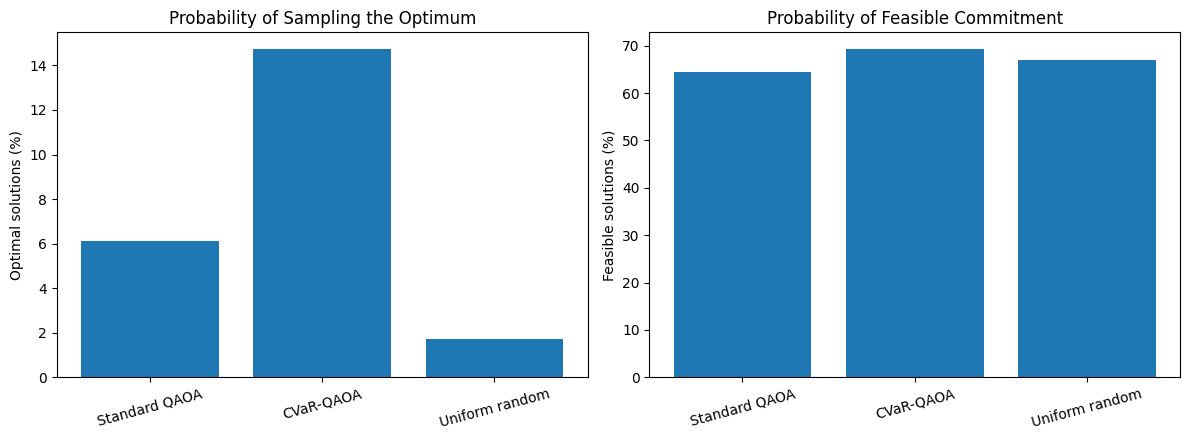

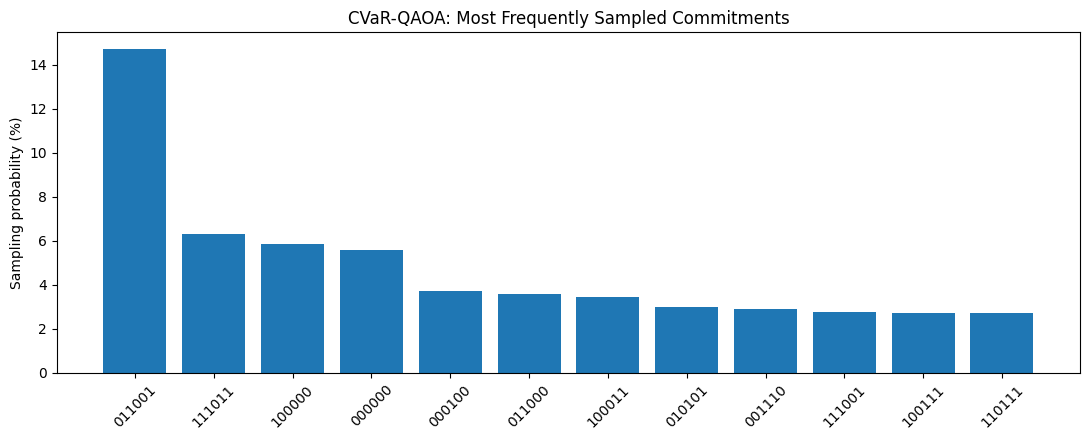

Saved benchmark table, measurement counts, and figures.


In [11]:
import matplotlib.pyplot as plt

# Save results
results_dir.mkdir(parents=True, exist_ok=True)

benchmark_df.to_csv(
    results_dir / "quantum_benchmark.csv",
    index=False
)

with open(results_dir / "measurement_counts.json", "w") as f:
    json.dump({
        "shots_per_method": SHOTS,
        "standard_qaoa": standard_counts,
        "cvar_qaoa": cvar_counts,
        "uniform_random": dict(random_counts)
    }, f, indent=2)

# Plot optimal and feasible sampling rates
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

methods = benchmark_df["Method"]

axes[0].bar(methods, benchmark_df["Optimal (%)"])
axes[0].set_title("Probability of Sampling the Optimum")
axes[0].set_ylabel("Optimal solutions (%)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(methods, benchmark_df["Feasible (%)"])
axes[1].set_title("Probability of Feasible Commitment")
axes[1].set_ylabel("Feasible solutions (%)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()

plt.savefig(
    results_dir / "qaoa_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Plot CVaR-QAOA bitstring distribution
top = sorted(
    cvar_counts.items(),
    key=lambda item: item[1],
    reverse=True
)[:12]

labels = [x[0] for x in top]
values = [100 * x[1] / SHOTS for x in top]

plt.figure(figsize=(11, 4.5))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.ylabel("Sampling probability (%)")
plt.title("CVaR-QAOA: Most Frequently Sampled Commitments")
plt.tight_layout()

plt.savefig(
    results_dir / "cvar_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved benchmark table, measurement counts, and figures.")

## Comparison Under Matched Optimisation Settings

The initial QAOA and CVaR-QAOA experiments used different numbers of optimiser restarts and maximum iterations.

To improve comparability, we repeat the experiments using identical initial parameters, three restarts, and the same maximum iteration limit.

We additionally record optimisation time and the number of objective-function evaluations.

Although the settings are matched, the actual numbers of function evaluations and execution times may differ because the optimiser can terminate early. Consequently, the experiment should not be interpreted as a strictly equal-computational-cost comparison.

In [12]:
import time

DEPTH = 2
RESTARTS = 3
MAXITER = 250
SHOTS = 4096

rng = np.random.default_rng(123)

# Identical initial parameters for both methods
initial_points = [
    np.concatenate([
        rng.uniform(0, 2*np.pi, DEPTH),
        rng.uniform(0, np.pi/2, DEPTH)
    ])
    for _ in range(RESTARTS)
]

def controlled_optimisation(cvar_fraction):
    start = time.perf_counter()

    solutions = []
    total_evaluations = 0

    for x0 in initial_points:
        result = minimize(
            qaoa_loss,
            x0=x0,
            args=(DEPTH, cvar_fraction),
            method="COBYLA",
            options={
                "maxiter": MAXITER,
                "rhobeg": 0.4,
                "tol": 1e-3
            }
        )

        solutions.append(result)
        total_evaluations += result.nfev

    best_result = min(solutions, key=lambda r: r.fun)

    return {
        "result": best_result,
        "time": time.perf_counter() - start,
        "evaluations": total_evaluations
    }


print("Optimising Standard QAOA...")
standard_fit = controlled_optimisation(1.0)

print("Optimising CVaR-QAOA...")
cvar_fit = controlled_optimisation(0.2)

# Sample both optimised circuits
standard_counts_fair = simulate_qaoa(
    standard_fit["result"], shots=SHOTS
)

cvar_counts_fair = simulate_qaoa(
    cvar_fit["result"], shots=SHOTS
)

rows = []

for name, fit, counts in [
    ("Standard QAOA", standard_fit, standard_counts_fair),
    ("CVaR-QAOA", cvar_fit, cvar_counts_fair)
]:
    row = calculate_metrics(name, counts)

    row["Optimisation time (s)"] = fit["time"]
    row["Function evaluations"] = fit["evaluations"]

    rows.append(row)

rows.append(calculate_metrics("Uniform random", random_counts))

fair_df = pd.DataFrame(rows)

display(fair_df.round(3))

fair_df.to_csv(
    results_dir / "controlled_comparison.csv",
    index=False
)

Optimising Standard QAOA...
Optimising CVaR-QAOA...


,Method,Optimal (%),Feasible (%),Mean feasible cost,Best sampled cost,Best gap (%),Optimisation time (s),Function evaluations
0,Standard QAOA,6.104,64.502,11866.034,4278.46,0.0,0.769,169.0
1,CVaR-QAOA,14.746,69.360,11272.751,4278.46,0.0,2.079,445.0
2,Uniform random,1.709,67.090,12543.009,4278.46,0.0,NaN,NaN
